## Simple Linear Regression

In [4]:
import pandas as pd

df = pd.read_csv("student_scores.csv")
df.head(10)

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


In [30]:
df.shape

(25, 2)

In [26]:
#ML operations rely on matrix multiplications which requires X to be 2D matrix
X = df[['Hours']] #sckit-learn requires input features X to be a 2D array
Y = df['Scores']

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [17]:
x_train.shape, x_test.shape, y_train.shape

((20, 1), (5, 1), (20,))

In [34]:
y_pred = model.predict(x_test)
y_test,y_pred

(14    17
 4     30
 7     60
 1     47
 2     27
 Name: Scores, dtype: int64,
 array([14.22032624, 37.44558349, 56.79996453, 52.92908832, 34.54242633]))

In [37]:
# Create a comparison table
df_comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Error': y_test-y_pred})
print(df_comparison)

    Actual  Predicted     Error
14      17  14.220326  2.779674
4       30  37.445583 -7.445583
7       60  56.799965  3.200035
1       47  52.929088 -5.929088
2       27  34.542426 -7.542426


In [19]:
model.score(x_train, y_train)

0.9553943785388819

In [20]:
model.score(x_test, y_test)

0.8591710843964244

In [21]:
c = model.intercept_
m = model.coef_

Prediction

In [22]:
model.predict([[6.4]])

C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([65.509436])

In [23]:
y = m*(6.4) + c
y

array([65.509436])

In [24]:
v = 6.4
import numpy as np
va = np.array(6.4)
va

array(6.4)

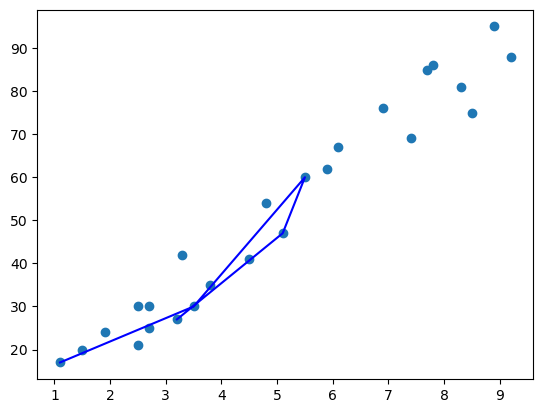

In [67]:
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.plot(x_test, y_test, color='blue')
plt.show()
#this plot is non straight line because its made of x_test, adn we know that before train_test_split, Ml shuffles the dataset

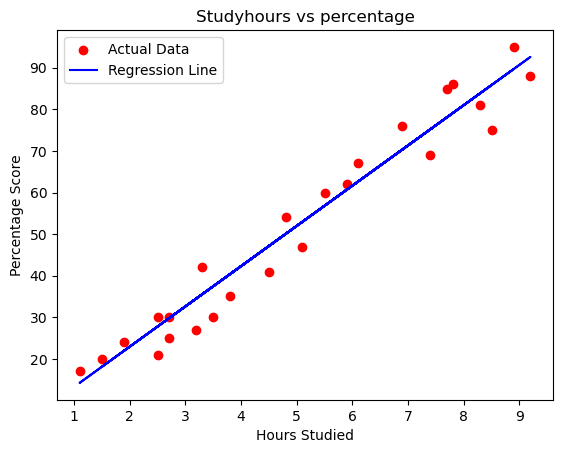

In [50]:
plt.scatter(X,Y,color='red', label='Actual Data')
plt.plot (X, model.predict(X), color='blue', label='Regression Line')
plt.title('Studyhours vs percentage')
plt.xlabel('Hours Studied')
plt.ylabel('Percentage Score')
plt.legend()
plt.show()

C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


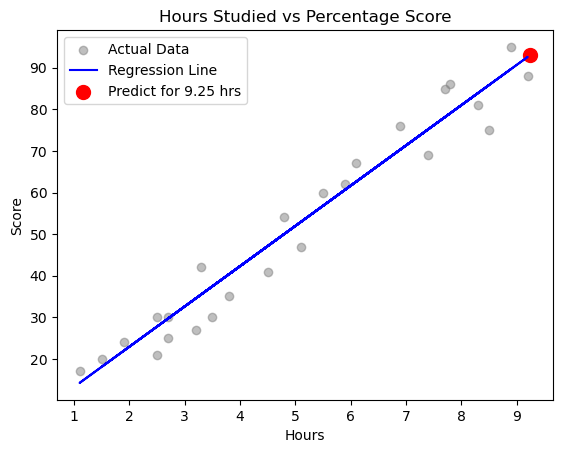

In [66]:
import matplotlib.pyplot as plt

# 1. Get the prediction for 9.25 hours
hours = 9.25
# We wrap it in [[ ]] because the model expects a 2D array (matrix)
prediction = model.predict([[hours]])

# 2. Plot the general data and regression line
plt.scatter(X, Y, color='gray', alpha=0.5, label='Actual Data') 
plt.plot(X, model.predict(X), color='blue', label='Regression Line')

# 3. Plot the SPECIAL POINT (Different color and larger size)
plt.scatter(hours, prediction, color='red', s=100, label=f'Predict for {hours} hrs')

# 4. Add Labels (Crucial for Viva!)
plt.title('Hours Studied vs Percentage Score')
plt.xlabel('Hours')
plt.ylabel('Score')
plt.legend()
plt.show()


## Multi-Student

In [52]:
mdf = pd.read_csv("student_multi.csv")
mdf.columns

Index(['Hours', 'IQ', 'Sleep', 'Scores'], dtype='object')

In [53]:
mdf.head(10)

,Hours,IQ,Sleep,Scores
0,1.0,90,5,35
1,1.5,92,6,38
2,2.0,95,6,42
3,2.2,97,6,44
4,2.5,98,7,47
5,2.8,100,6,49
6,3.0,102,7,52
7,3.2,103,6,54
8,3.5,105,7,57
9,3.8,107,7,59


In [54]:
mX = mdf[['Hours', 'IQ', 'Sleep']]
mY = mdf['Scores']


In [55]:
mx_train, mx_test, my_train, my_test = train_test_split(mX,mY, test_size=0.2)

In [56]:
m_model = LinearRegression()
m_model.fit(mx_train, my_train)

LinearRegression()

In [57]:
my_pred = m_model.predict(mx_test)

my_pred, my_test

(array([ 87.58436598,  92.23622756, 122.31628071,  67.55388525,
        129.23516813,  44.775478  ,  99.05697277, 103.28683863,
         52.53835688, 121.83538002]),
 23     88
 25     92
 42    122
 13     68
 45    128
 2      42
 30    101
 32    104
 6      52
 41    120
 Name: Scores, dtype: int64)

In [63]:
mdf_data=pd.DataFrame({'actual': my_test,'predicted': my_pred})
mdf_data

,actual,predicted
23,88,87.584366
25,92,92.236228
42,122,122.316281
13,68,67.553885
45,128,129.235168
2,42,44.775478
30,101,99.056973
32,104,103.286839
6,52,52.538357
41,120,121.835380


In [64]:
trnscore = m_model.score(mx_train, my_train)
tstscore = m_model.score(mx_test, my_test)

trnscore, tstscore

(0.9984662214584483, 0.9977585229007233)

In [65]:
m_model.predict([[7.3,120,7]])

C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([97.18276338])

### RMSE, SME, MEAN ERROR

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_true = my_test
mae = mean_absolute_error(y_true, my_pred)
mse = mean_squared_error(y_true, my_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, my_pred)
adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - y_true.ndim - 1)

residuals = np.array(y_true) - np.array(my_pred)

print("residuls:", residuals)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)

residuls: [ 0.28651251  1.08191428  1.77688934  1.41801604 -1.68603826 -0.03804549
  0.78156703  1.89833241 -1.01383474 -2.45730241]
MAE: 1.2438452501420343
MSE: 2.0545614574285214
RMSE: 1.4333741512349527
R2: 0.9974815686772306
Adjusted R2: 0.9971667647618844
